# Movimentação pré-eleição em mercados presidenciais --- Polymarket no BigQuery

## 0. Introdução

Política é parecido com futebol: Você escolhe um time (partido), adora seus jogadres (candidatos), torce ardentemente por eles, fica muito bravo quando eles fazem burrada em TV nacional e mais bravo ainda com os outros times, existindo até rivalidades históricas entre times.

Naturalmente política pode ser muito mais sério, mas o paralelo anedodicamente existe e iremos explorar essa similaridade de forma semelhante ao [exemplo fornecido pelo Carlos](https://colab.research.google.com/drive/1hBLufaANuG5hQ0Lfs9_RVlRaIGG7yRcb?usp=sharing#scrollTo=8VRKtYo2kyFT) e ver se esse paralelo se mostra nos dados.

É importante ressaltar que esse notebook é fortemente derivado do exemplo do Carlos, e a compreensão desse notebook exige que o notebook do Carlos esteja aberto para fazer as comparações.

**Pergunta Central:** As probabilidades negociadas em um mercado de eleição se comportam de forma parecida com as de um mercado de futebol? Ele também tem um comportamento parecido no dia de revelar o vencedor? Conseguimos localizar esses movimentos com consultas semelhantes? Quais adaptações são necessárias? Se não conseguimos, existe alguma consulta capaz de localizá-los?

**Hipótese testável:** Nos dias ou horas anteriores ao evento existem deslocamentos de preços maiores que o ruído normal do mercado, semelhante ao que acontece com mercados de futebol.

### 0.1 Bibliotecas e configurações

Bibliotecas usadas:

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from IPython import display

Configurando gráficos:

In [51]:
# Paleta fixa e sóbria: uma cor por papel, nunca por posição
COR_PRECO   = "#2563eb"   # azul: linha de preço
COR_BANDA   = "#93c5fd"   # azul claro: faixa min-max do preço
COR_VOLUME  = "#9ca3af"   # cinza: volume (contexto)
COR_DESTAQUE = "#ea580c"  # laranja: eventos/anotações

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

Funções convenientes:

In [52]:
def carrega(nome, prefix='./dados/'):
    """Lê um CSV exportado do BigQuery, convertendo timestamps (sufixo ' UTC')."""
    df = pd.read_csv(prefix+nome)
    for col in df.columns:
        if df[col].dtype == object and df[col].astype(str).str.endswith("UTC").any():
            df[col] = pd.to_datetime(df[col].str.replace(" UTC", "", regex=False))
    return df

## 1. Selecionando Mercados 

### 1.1 Procurando mercados eleitorais

Primeiro, vamos procurar pelos mercados que queremos explorar. 

Depois de ter dado uma olhadinha no site da Polymarket, vamos procurar na base de dados alguns mercados sobre eleições presidenciais. Elas podem ser em qualquer lugar no mundo, não necessariamente no Brasil. 

```sql
SELECT market_id, question, end_date
    FROM `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE   LOWER(question) LIKE '%presidential election%'
        AND end_date <= '2026-07-25 23:59:59';
```

In [53]:
q1 = carrega("q1_mercados_eleicao_finalizados.csv")
q1

,market_id,question,end_date
0,126965,Who will win the 2021 Peruvian Presidential El...,2021-06-06 00:00:00.000000 UTC
1,47,Which party will win Florida in the 2020 presi...,2020-11-20 00:00:00.000000 UTC
2,40,Will Trump win the 2020 U.S. presidential elec...,2020-11-20 00:00:00.000000 UTC
3,206736,What will the Margin of Victory be in the 2021...,2021-06-18 00:00:00.000000 UTC
4,240027,Who will win the 2021 Chilean presidential ele...,2021-12-23 00:00:00.000000 UTC
...,...,...,...
1284,647561,Will Catherine Connolly win the Irish Presiden...,2026-04-16 00:24:51.000000 UTC
1285,647557,Will Catherine Connolly win the Irish Presiden...,2026-04-16 00:24:51.000000 UTC
1286,647560,Will Catherine Connolly win the Irish Presiden...,2026-04-16 00:24:51.000000 UTC
1287,647559,Will Catherine Connolly win the Irish Presiden...,2026-04-16 00:24:51.000000 UTC


Temos muitos mercados sobre isso! Inclusive alguns brasileiros, como:

- 601819: Will Luiz Inácio Lula da Silva win the 2026 Brazilian presidential election?
- 601826: Will Flávio Bolsonaro win the 2026 Brazilian presidential election?

Porém, esses bancos não são _tão_ volumosos. Podemos procurar por alguns outros com mais dados para conseguir informações históricas. Melhor ainda: vamos analisar vários mercados sobre eleições passadas, não necessariamente só do Brasil!

### 1.2 Quantidade e volume

```SQL
SELECT
        COUNT(*)                    AS n_mercados,
        ROUND(SUM(volume) / 1e6, 1) AS volume_total_musd,
        ROUND(AVG(volume), 0)       AS volume_medio_usd
    FROM `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE   LOWER(question) LIKE '%presidential election%'
        AND end_date <= '2026-07-25 23:59:59';
```

In [54]:
q2a = carrega('q2a_quantidade_e_volume.csv')
q2a

,n_mercados,volume_total_musd,volume_medio_usd
0,1289,5869.1,4553231.0


Podemos ver que temos bastantes dados (**1289 mercados**) com volume **total** de **US\$5.869,10 milhões** e **média** de **US\$4.553.231,00**. Em comparação com os mercados de futebol, por mais que nossos dados tenham menos mercados (futebol tem 22.299), o volume total (US\$2.450 milhões) e médio (US\$110 mil) são maiores!

```SQL
SELECT
        market_id, 
        question, 
        event_title,
        ROUND(volume, 0) AS volume_usd, 
        created_at, 
        end_date
    FROM `even-continuity-441808-j0.polymarket_optimized.markets`
    WHERE LOWER(question) LIKE '%presidential election%'
        AND end_date <= '2026-07-25 23:59:59'
        -- AND LOWER(question) LIKE '%brazil%'
    ORDER BY volume DESC
    LIMIT 20;
```

In [55]:
q2b = carrega('q2b_top_20_eleicoes.csv')

# Janela de vida do mercado: quantos dias do resultado ele abre?
q2b["dias_de_vida"] = (pd.to_datetime(q2b["end_date"]) - pd.to_datetime(q2b["created_at"])).dt.days

q2b

,market_id,question,event_title,volume_usd,created_at,end_date,dias_de_vida
0,253591,Will Donald Trump win the 2024 US Presidential...,Presidential Election Winner 2024,1.531479e+09,2024-01-04 17:33:51.000000 UTC,2024-11-05 12:00:00.000000 UTC,305
1,253597,Will Kamala Harris win the 2024 US Presidentia...,Presidential Election Winner 2024,1.037039e+09,2024-01-04 17:40:17.000000 UTC,2024-11-04 12:00:00.000000 UTC,304
2,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,(Old) Romania Election,3.265077e+08,2024-11-07 23:53:29.000000 UTC,2024-12-08 12:00:00.000000 UTC,30
3,253642,Will any other Republican Politician win the 2...,Presidential Election Winner 2024,2.416551e+08,2024-01-06 19:52:35.000000 UTC,2024-11-05 00:00:00.000000 UTC,303
4,253609,Will Michelle Obama win the 2024 US Presidenti...,Presidential Election Winner 2024,1.533823e+08,2024-01-05 20:53:17.000000 UTC,2024-11-05 00:00:00.000000 UTC,304
5,253595,Will Robert F. Kennedy Jr. win the 2024 US Pre...,Presidential Election Winner 2024,1.416051e+08,2024-01-04 17:39:07.000000 UTC,2024-11-04 12:00:00.000000 UTC,304
6,253706,Will Donald Trump win the popular vote in the ...,Popular Vote Winner 2024,1.199326e+08,2024-01-09 18:05:18.000000 UTC,2024-11-05 12:00:00.000000 UTC,300
7,253641,Will any other Democratic Politician win the 2...,Presidential Election Winner 2024,1.165582e+08,2024-01-06 19:52:35.000000 UTC,2024-11-05 00:00:00.000000 UTC,303
8,529278,Will Frances Fitzgerald win the Irish Presiden...,Ireland Presidential Election,1.150672e+08,2025-03-20 19:34:21.000000 UTC,2025-11-11 12:00:00.000000 UTC,235
9,253593,Will Nikki Haley win the 2024 US Presidential ...,Presidential Election Winner 2024,1.075292e+08,2024-01-04 17:36:47.000000 UTC,2024-11-05 00:00:00.000000 UTC,305


In [56]:
q2b_BR = carrega('q2b_BR_top_20_eleicoes.csv')

# Janela de vida do mercado: quantos dias do resultado ele abre?
q2b_BR["dias_de_vida"] = (pd.to_datetime(q2b_BR["end_date"]) - pd.to_datetime(q2b_BR["created_at"])).dt.days

q2b_BR

,market_id,question,event_title,volume_usd,created_at,end_date,dias_de_vida
0,240587,Will Luiz da Silva win 2022 Presidential Elect...,Who will win the 2022 Brazilian presidential e...,264365.0,2022-01-11 23:04:47.000000 UTC,2022-10-30 00:00:00.000000 UTC,291
1,240588,Will Jair Bolsonaro win 2022 Presidential Elec...,Who will win the 2022 Brazilian presidential e...,64027.0,2022-01-11 23:24:40.000000 UTC,2022-10-30 00:00:00.000000 UTC,291
2,240590,Will João Doria win 2022 Presidential Election...,Who will win the 2022 Brazilian presidential e...,2683.0,2022-01-11 23:39:28.000000 UTC,2022-10-30 00:00:00.000000 UTC,291
3,240589,Will Sergio Moro win 2022 Presidential Electio...,Who will win the 2022 Brazilian presidential e...,2477.0,2022-01-11 23:32:32.000000 UTC,2022-10-30 00:00:00.000000 UTC,291


Aqui, podemos ver outra diferença que podemos ver em relação aos mercados de futebol: O tempo de vida é muito maior. Dentre os 20 maiores, os mercados de jogos tem 13 dias de vida, enquanto os de eleições tem aproximadamente **300 dias** de duração. Uau!

Talvez isso justifique o maior volume que vimos anteriormente, mas não podemos dizer com certeza.

Para a análise específica, vamos o mercado:
- _(253591) `Will Donald Trump win the 2024 US Presidential Election?`_

por ser o de maior volume, mas se quisessemos ter algo mais centrado no Brasil, poderiamos ter usado

- _(240587) `Will Luiz da Silva win 2022 Presidential Elections in Brazil?`_
  
por ser o de maior volume no Brasil. Em todas as queries subsequentes, para olhar especificamente para o Brasil, bastaria adiocionar `LOWER(question) LIKE '%brazil%'` na clausula `WHERE`, assim como está comentado na query dessa sessão. No entanto, o mercado do Trump em 2024 é notoriamente maior em volume, então vamos estar sempre usando ele para análises singulares.

## 2 Análise

Vamos dar uma olhada nos dados!

### 2.1 Análise de caso

Primeiramente, vamos ver um caso específico. Como dito na sessão passada, estaremos usando o mercado 253591 (`Will Donald Trump win the 2024 US Presidential Election?`), dado o seu volume massivo.

A query abaixo é diferente da feita pelo Carlos. Isso se deve a forte polarização desse mercado em relação ao dos jogos de futebol. No Polymarket, a compra de uma ação em alguns mercados são dados por duas opções: `YES` e `NO`. Dessa forma, quando pegamos o preço médio do dataset `polymarket_mart.v_market_daily_snapshot`, temos a média desses dois preços, fazendo com que seu valor flutue sempre nas proximidades de 0.5, especialmente no caso de um mercado polarizado como esse. 

No nosso caso, queremos apenas os dados marcados como `YES`. Como não existia uma snapshot pra isso, precisei fazer minha próprioa query, que pega todos os valores do mercado do seu início até seu fim.

```SQL
SELECT 
    trade_timestamp momento, 
    price preco, 
    usd_amount dolares, 
    token_amount quantidade_tokens, 
    maker_direction, 
    taker_direction, 
    nonusdc_side voto
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
    WHERE market_id = '253591'
        AND trade_timestamp <= '2024-11-06 23:59:59'
        AND trade_timestamp >= '2024-01-05 00:00:00'
    ORDER BY trade_timestamp ASC;
```

In [57]:
q3a = carrega("q3a_eleicao_us_trump_2024.csv")
q3a["momento"] = pd.to_datetime(q3a["momento"])
q3a

,momento,preco,dolares,quantidade_tokens,maker_direction,taker_direction,voto
0,2024-01-05 02:37:20+00:00,0.420,84.00,200.00,SELL,BUY,token1
1,2024-01-05 02:37:20+00:00,0.580,22.10,38.10,BUY,SELL,token2
2,2024-01-05 03:35:12+00:00,0.590,5.90,10.00,SELL,BUY,token2
3,2024-01-05 03:35:12+00:00,0.590,118.00,200.00,SELL,BUY,token2
4,2024-01-05 03:38:44+00:00,0.590,16.57,28.09,BUY,SELL,token2
...,...,...,...,...,...,...,...
2749419,2024-11-06 11:21:55+00:00,0.998,328.82,329.48,BUY,SELL,token1
2749420,2024-11-06 11:21:55+00:00,0.998,904.23,906.04,BUY,SELL,token1
2749421,2024-11-06 11:22:03+00:00,0.001,0.00,0.35,BUY,SELL,token2
2749422,2024-11-06 11:22:05+00:00,0.998,5.39,5.40,BUY,SELL,token1


O campo `voto` é o indicador do tipo da compra, sendo `token1` o valor que representa `YES` E `token2` o que representa `NO`. Dessa forma, para essa análise em específico, queremos pegar apenas as linhas com `token1`. Esse filtro poderia ter sido feito direto em SQL, porém como essa query é necessariamente bem pesada, mantive essa coluna pois, quem sabe, essa informação poderá ser usada em outra análise. 

Além desse filtro, vamos agregar essas informações em diferentes níveis de granularidade para ter múltiplas perspectivas do comportamento.

In [58]:
q3a_yes = q3a[q3a['voto'] == 'token1'][['momento', 'preco', 'dolares', 'quantidade_tokens']]

q3a_dict = {}
freqs = ['D', 'W', 'ME']

for freq in freqs:
    q3a_dict[freq] = q3a_yes.groupby(pd.Grouper(key='momento', freq=freq)).agg(
        preco_medio=('preco', 'mean'),
        preco_max=('preco', 'max'),
        preco_min=('preco', 'min'),
        dolares_total=('dolares', 'sum'),
        dolares_mean=('dolares', 'sum'),
        quantidade_total_tokens=('quantidade_tokens', 'sum'),
        quantidade_media_tokens=('quantidade_tokens', 'mean'),
    ).reset_index()

q3a_dict['ME']['momento'] = q3a_dict[freq]['momento'].dt.month
q3a_dict

{'D':                       momento  preco_medio  preco_max  preco_min  \
 0   2024-01-05 00:00:00+00:00     0.403415      0.420      0.400   
 1   2024-01-06 00:00:00+00:00     0.404118      0.410      0.400   
 2   2024-01-07 00:00:00+00:00     0.421538      0.520      0.400   
 3   2024-01-08 00:00:00+00:00     0.469091      0.470      0.460   
 4   2024-01-09 00:00:00+00:00     0.450000      0.450      0.450   
 ..                        ...          ...        ...        ...   
 302 2024-11-02 00:00:00+00:00     0.584807      0.597      0.549   
 303 2024-11-03 00:00:00+00:00     0.551736      0.580      0.526   
 304 2024-11-04 00:00:00+00:00     0.574520      0.628      0.539   
 305 2024-11-05 00:00:00+00:00     0.617576      0.945      0.568   
 306 2024-11-06 00:00:00+00:00     0.971243      0.999      0.860   
 
      dolares_total  dolares_mean  quantidade_total_tokens  \
 0          4419.66       4419.66                 10883.07   
 1         19511.37      19511.37        

In [59]:
dia_resultado = pd.Timestamp('2024-11-05T12', tz='UTC')
dia_resultado

Timestamp('2024-11-05 12:00:00+0000', tz='UTC')

Esse código para gráfico foi inteiramente feito pelo Carlos, com algumas pequenas alterações para se adequar ao tema. 

In [60]:
def grafico_preco_e_volume_no_tempo(dados, momento_resultado, dias_previos=0):

    q3p = dados[dados["momento"] <= momento_resultado]
    if dias_previos > 0:
        q3p = q3p.tail(dias_previos)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

    # Preço: linha do preço médio + faixa min-max do dia
    ax1.fill_between(q3p["momento"], q3p["preco_min"], q3p["preco_max"],
                    color=COR_BANDA, alpha=0.45, label="faixa do dia (mín–máx)")
    ax1.plot(q3p["momento"], q3p["preco_medio"], color=COR_PRECO, lw=2,
            marker="o", ms=4, label="preço médio diário")
    ax1.axvline(momento_resultado, color=COR_DESTAQUE, ls="--", lw=1.5)
    ax1.annotate("dia do resultado", xy=(momento_resultado, 0.9), xytext=(-90, 0),
                textcoords="offset points", color=COR_DESTAQUE, fontweight="bold")
    ax1.set_ylabel("preço (prob. implícita do PSG)")
    ax1.set_ylim(0, 1)
    ax1.legend(loc="upper left", frameon=False)
    title = "Trump como presidente dos USA em 2024 — preço e volume"
    if dias_previos > 0:
        title += f" ({dias_previos} dias)"
    else:
            title += ', da abertura ao fechamento'
    ax1.set_title(title)

    # Volume: barras em escala log (varia de $200 a $7M)
    ax2.bar(q3p["momento"], q3p["dolares_total"], color=COR_VOLUME, width=0.7)
    ax2.set_yscale("log")
    ax2.set_ylabel("volume diário (US$, log)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax2.axvline(momento_resultado, color=COR_DESTAQUE, ls="--", lw=1.5)

    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


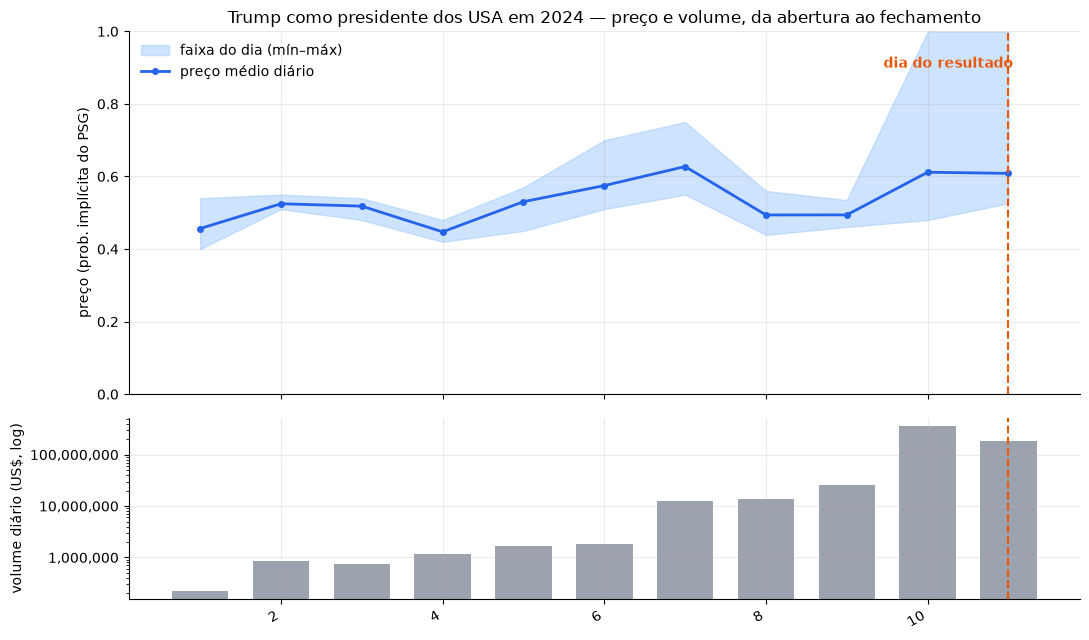

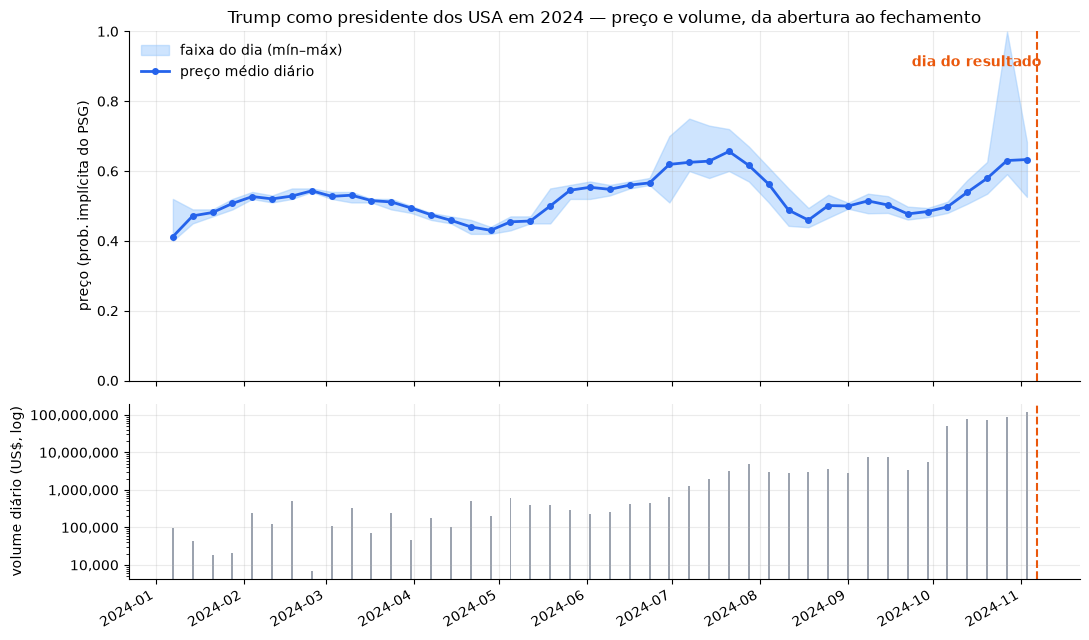

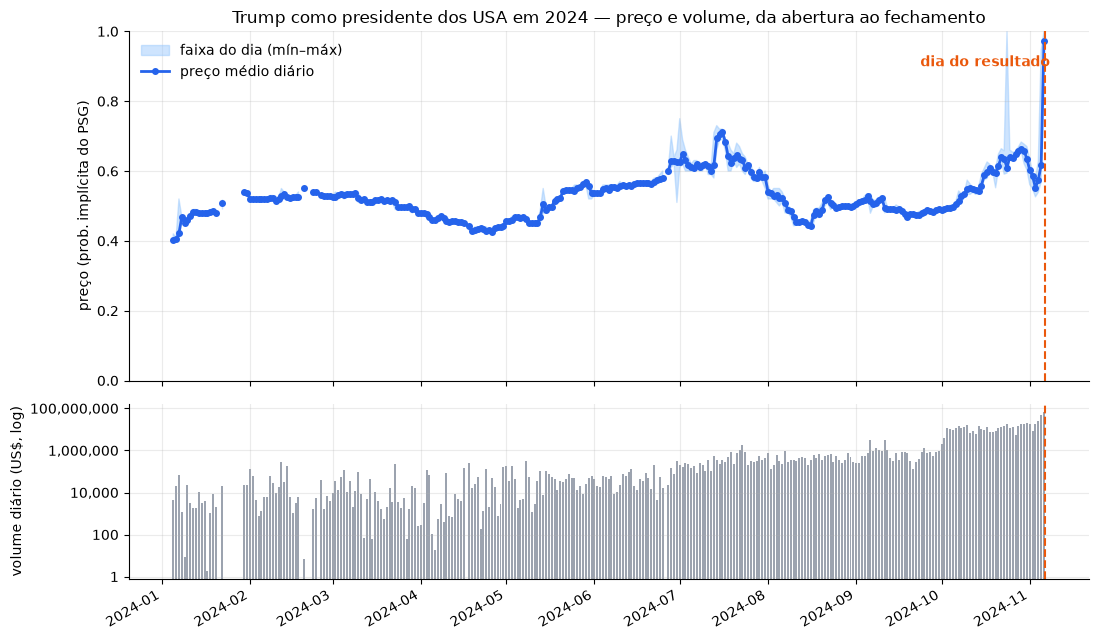

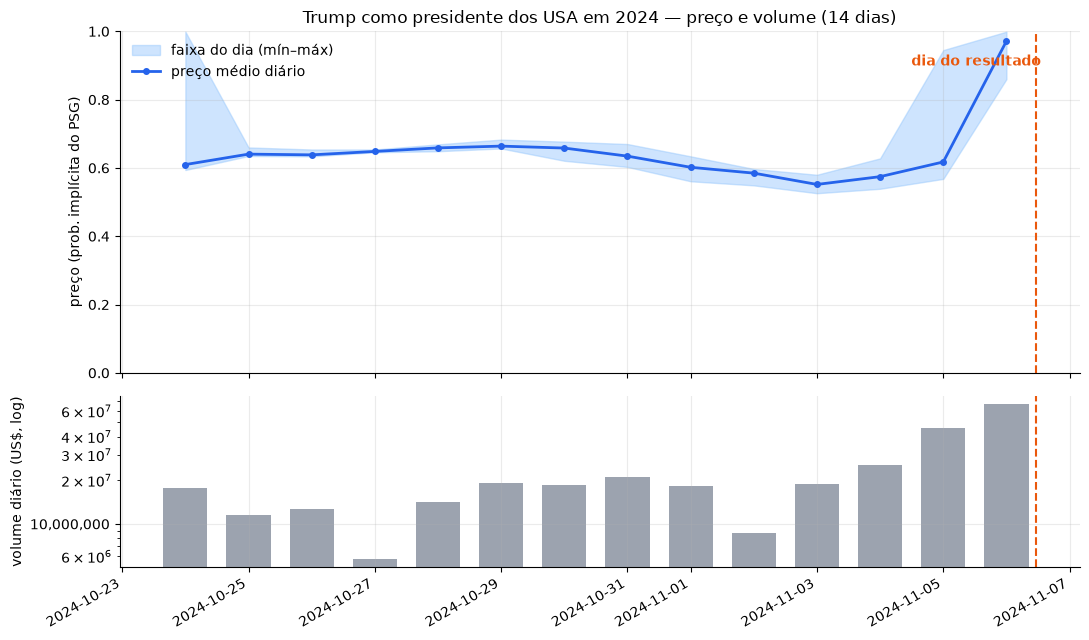

In [61]:
dia_resultado = q3a['momento'].iloc[-2]
grafico_preco_e_volume_no_tempo(q3a_dict['ME'], dia_resultado.month)
grafico_preco_e_volume_no_tempo(q3a_dict['W'], dia_resultado)
grafico_preco_e_volume_no_tempo(q3a_dict['D'], dia_resultado)
grafico_preco_e_volume_no_tempo(q3a_dict['D'], dia_resultado, 14)

Podemos ver que, da mesma forma que no futebol, chegando perto do dia do resultado, a movimentação aumenta muito. No caso da eleição do Trump, essa influência foi positiva, aumentando a quantidade de votos `YES`. Além disso, o volume de compras e vendas também cresceu se aproximando do resultado.

É interessante ressaltar que o último mês, por mais que tenha um volume um pouco menor que o penútimo, durou apenas 5 dias antes do resultado, indicando uma alta movimentação.  

No entanto, existem outros picos nesse gráfico de preço além dos dias finais, como em 2024-06. A janela de duração desse mercado foi maior do que o mercado das partidas de futebol, como já tinhamos visto, abrindo a possibilidades que outros eventos políticos afetassem as compras e vendas, possivelmente justificando esses outros picos. Entender exatamente a razão por trás desses picos está fora do escopo atual.  

Uma forma diferente que poderiamos ter conseguido uma informação parecida é através da amplitude da média de vendas, considerando tanto os `YES` quanto `NO`, da forma que o Carlos fez. 

```SQL
SELECT
        trade_date, daily_trade_count,
        ROUND(daily_usd_volume, 0)                  AS volume_usd,
        ROUND(avg_trade_price, 3)                   AS preco_medio,
        ROUND(min_trade_price, 3)                   AS preco_min,
        ROUND(max_trade_price, 3)                   AS preco_max,
        ROUND(max_trade_price - min_trade_price, 3) AS amplitude_dia
    FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily_snapshot`
    WHERE market_id = '240587'
    ORDER BY trade_date;
```

In [62]:
q3a2 = carrega("q3a2_eleicao_trump_2024_media_nao_separada.csv")
q3a2["momento"] = pd.to_datetime(q3a2["trade_date"])
q3a2

,trade_date,daily_trade_count,dolares_total,preco_medio,preco_min,preco_max,amplitude_dia,momento
0,2024-01-05,80,19855.0,0.495,0.400,0.600,0.200,2024-01-05
1,2024-01-06,58,27677.0,0.481,0.400,0.600,0.200,2024-01-06
2,2024-01-07,114,328853.0,0.475,0.400,0.600,0.200,2024-01-07
3,2024-01-08,38,41403.0,0.514,0.460,0.540,0.080,2024-01-08
4,2024-01-09,19,2276.0,0.537,0.450,0.560,0.110,2024-01-09
...,...,...,...,...,...,...,...,...
302,2024-11-02,55046,12537700.0,0.525,0.403,0.597,0.194,2024-11-02
303,2024-11-03,70086,28932061.0,0.519,0.420,0.580,0.160,2024-11-03
304,2024-11-04,127600,37573112.0,0.521,0.372,0.628,0.256,2024-11-04
305,2024-11-05,150892,67745130.0,0.519,0.060,0.945,0.885,2024-11-05


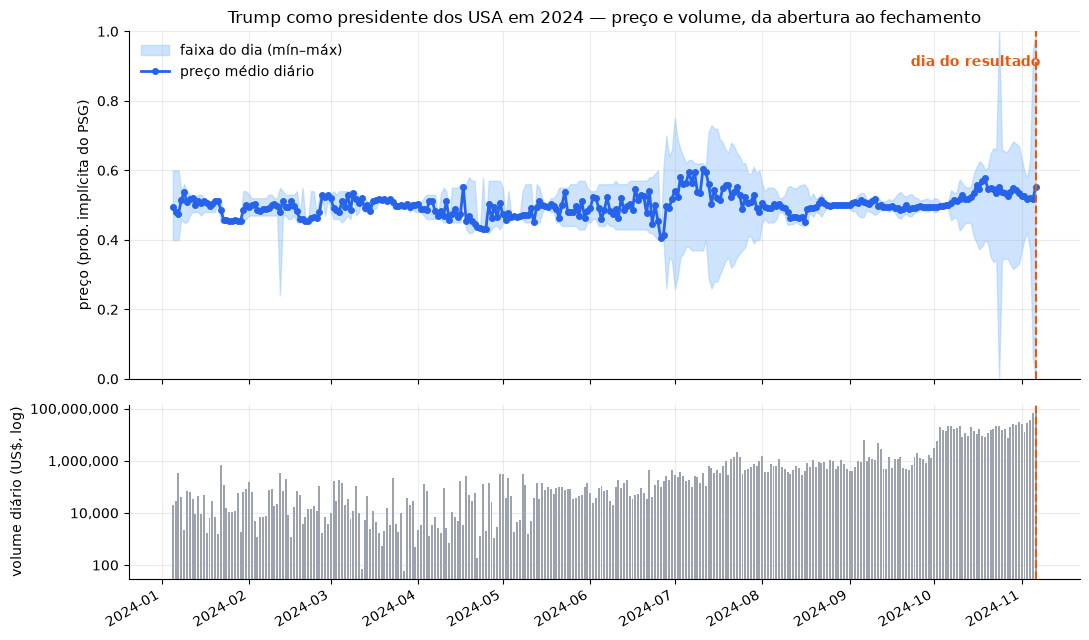

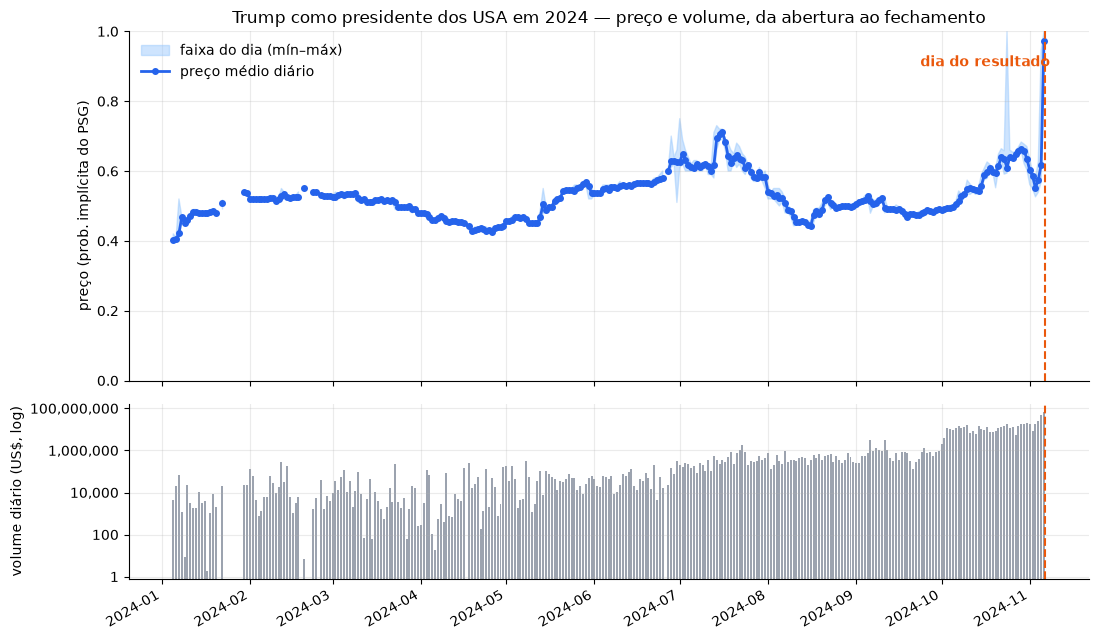

In [63]:
dia_resultado2 = q3a2['momento'].max()
grafico_preco_e_volume_no_tempo(q3a2, dia_resultado2)
grafico_preco_e_volume_no_tempo(q3a_dict['D'], dia_resultado)


Comparando os gráficos, vemos que os picos na média do de baixo geralmente ocorrem ao mesmo tempo que os picos da amplitude do de cima. Como temos apenas duas opções de valores, `YES` e `NO`, é natural que um deles seja o mínimo e o outro o máximo, aproximadamente, pelo menos. 

Uma amplitude alta significa valores nos extremos, e são nessas situações que estamos interessados! Portanto, como podemos tirar a amplitude média dos dados em snapshot, será muito mais barato usá-los. Portanto, vamos seguir com a estratégia do Carlos. 

### 2.2 Vários casos

Agora vamos ver se isso é uma tendência de mercados sobre eleições ou era apenas no caso do Trump em 2024. Para isso, usaremos a média diária da amplitude dos preços.

A partir daqui, todas as queries e gráficos são de autoria do Carlos, com algumas alterações minhas para se adequar aos meus dados.

```SQL
SELECT
        DATE_DIFF(DATE(m.end_date), d.trade_date, DAY)        AS dias_antes_do_resultado,
        COUNT(*)                                              AS observacoes,
        ROUND(AVG(d.max_trade_price - d.min_trade_price), 4)  AS amplitude_media,
        ROUND(APPROX_QUANTILES(d.max_trade_price - d.min_trade_price, 100)[OFFSET(90)], 4)
                                                                AS amplitude_p90,
        ROUND(AVG(d.daily_usd_volume), 0)                     AS volume_medio_usd
    FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` d
    JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m ON d.market_id = m.market_id
    WHERE LOWER(m.question) LIKE '%presidential election%'
        AND m.volume > 100000
    GROUP BY dias_antes_do_resultado
    HAVING dias_antes_do_resultado BETWEEN 0 AND 365
    ORDER BY dias_antes_do_resultado;
```

In [74]:
q4 = carrega("q4_amplitudes_por_dias_previos.csv")
q4

,dias_antes_do_resultado,observacoes,amplitude_media,amplitude_p90,volume_medio_usd
0,0,393,0.7199,0.998,293791.0
1,1,396,0.6029,0.997,164479.0
2,2,392,0.5764,0.995,117270.0
3,3,391,0.5003,0.992,94312.0
4,4,400,0.5209,0.994,133094.0
...,...,...,...,...,...
361,361,42,0.3962,0.985,778.0
362,362,44,0.5377,0.987,981.0
363,363,43,0.4334,0.985,427.0
364,364,42,0.4155,0.983,309.0


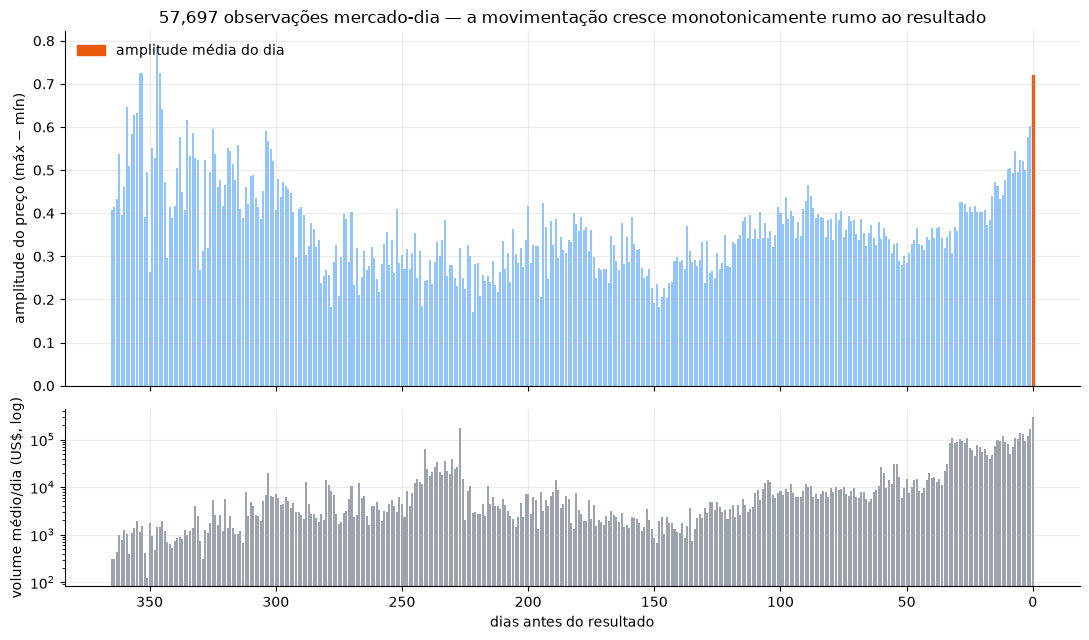

amplitude média dia 13 -> dia 1: 0.43 -> 0.60 (1.4x)
volume médio  dia 1 -> dia 0:  $164,479 -> $293,791 (2x)


In [ ]:
# Só até o dia 13: além disso a amostra despenca (mercados abrem ~13 dias antes)
q4_confiavel = q4[q4["dias_antes_do_resultado"] <= 365]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

x = q4_confiavel["dias_antes_do_resultado"]
ax1.bar(x, q4_confiavel["amplitude_media"], color=COR_BANDA, label="amplitude média do dia")

# destaca o dia 0, que é o resultado em si, não "pré-resultado"
barra_dia0 = ax1.patches[0]
barra_dia0.set_color(COR_DESTAQUE)
ax1.set_ylabel("amplitude do preço (máx − mín)")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title(f"{int(q4_confiavel['observacoes'].sum()):,} observações mercado-dia — ")

ax2.bar(x, q4_confiavel["volume_medio_usd"], color=COR_VOLUME)
ax2.set_yscale("log")
ax2.set_ylabel("volume médio/dia (US$, log)")
ax2.set_xlabel("dias antes do resultado")
ax2.invert_xaxis()   # lê da esquerda (longe do resultado) para a direita (dia do resultado)

plt.tight_layout()
plt.show()

# Números-chave citados no texto abaixo
razoes = q4.set_index("dias_antes_do_resultado")
print(f"amplitude média dia 13 -> dia 1: {razoes.loc[13,'amplitude_media']:.2f} -> "
      f"{razoes.loc[1,'amplitude_media']:.2f} "
      f"({razoes.loc[1,'amplitude_media']/razoes.loc[13,'amplitude_media']:.1f}x)")
print(f"volume médio  dia 1 -> dia 0:  ${razoes.loc[1,'volume_medio_usd']:,.0f} -> "
      f"${razoes.loc[0,'volume_medio_usd']:,.0f} "
      f"({razoes.loc[0,'volume_medio_usd']/razoes.loc[1,'volume_medio_usd']:.0f}x)")

A princípio, esse gráfico parace bem diferente do resultado sobre futebol. No entanto, os mercados de jogos foram analisados desde apenas 14 dias antes do resultado, enquanto esse foi analisado desde 365 dias antes. Se obervados apenas os 14 últimos dias (ou mesmo os 50 último), veremos que a movimentação cresce também monotonicamente rumo ao resultado!

## 3.3 Conclusão parcial
Até agora, jogos de futebol e eleições presidenciais se mostraram bem parecidas!

Por mais que eleições sejam eventos maiores, tanto em relevância quanto duração, seu comportamento se assemelha aos jogos no que diz respeito aos seus últimos dias: ambos os eventos ficam bem mais movimentado e polarizados nessa época. 

## 3 Alertas

Parece que eleições e jogos são realmente parecidos, mas será que os alertas de um funcionam no outro?

## 3.1 Alerta 1

A princípio, o alerta 1 não foi efetivo para jogos. Será que ele é efeitvo para eleições?

```SQL
WITH serie AS (
  SELECT
    d.market_id,
    DATE_DIFF(DATE(m.end_date), d.trade_date, DAY)  AS dias_antes_do_resultado,
    d.daily_trade_count,
    d.daily_usd_volume,
    d.max_trade_price - d.min_trade_price           AS amplitude_dia
  FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` d
  JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m ON d.market_id = m.market_id
  WHERE LOWER(question) LIKE '%presidential election%'
        AND end_date <= '2026-07-25 23:59:59'
    AND m.volume > 100000
    AND DATE_DIFF(DATE(m.end_date), d.trade_date, DAY) BETWEEN 1 AND 365
)
SELECT
  dias_antes_do_resultado,
  COUNT(*)                                                      AS dias_total,
  COUNTIF(daily_trade_count >= 30 AND daily_usd_volume >= 1000) AS dias_liquidos,
  ROUND(AVG(amplitude_dia), 3)                                  AS amp_media_todos,
  ROUND(AVG(IF(daily_trade_count >= 30 AND daily_usd_volume >= 1000,
               amplitude_dia, NULL)), 3)                        AS amp_media_liquida,
  ROUND(APPROX_QUANTILES(IF(daily_trade_count >= 30 AND daily_usd_volume >= 1000,
               amplitude_dia, NULL), 100)[OFFSET(50)], 3)       AS amp_mediana_liquida,
  ROUND(APPROX_QUANTILES(IF(daily_trade_count >= 30 AND daily_usd_volume >= 1000,
               amplitude_dia, NULL), 100)[OFFSET(90)], 3)       AS amp_p90_liquida
FROM serie
GROUP BY dias_antes_do_resultado
ORDER BY dias_antes_do_resultado;
```

In [79]:
q5 = carrega("q5_amplitudes_medias_de_dias_liquidos_e_totais.csv")
q5["pct_liquidos"] = (100 * q5["dias_liquidos"] / q5["dias_total"]).round(1)
q5

,dias_antes_do_resultado,dias_total,dias_liquidos,amp_media_todos,amp_media_liquida,amp_mediana_liquida,amp_p90_liquida,pct_liquidos
0,1,396,206,0.603,0.784,0.900,0.995,52.0
1,2,392,181,0.576,0.765,0.886,0.995,46.2
2,3,391,165,0.500,0.737,0.870,0.995,42.2
3,4,400,153,0.521,0.737,0.880,0.997,38.2
4,5,384,160,0.524,0.719,0.870,0.993,41.7
...,...,...,...,...,...,...,...,...
354,356,1,0,0.000,NaN,NaN,NaN,0.0
355,357,1,0,0.040,NaN,NaN,NaN,0.0
356,358,1,0,0.000,NaN,NaN,NaN,0.0
357,360,1,0,0.000,NaN,NaN,NaN,0.0


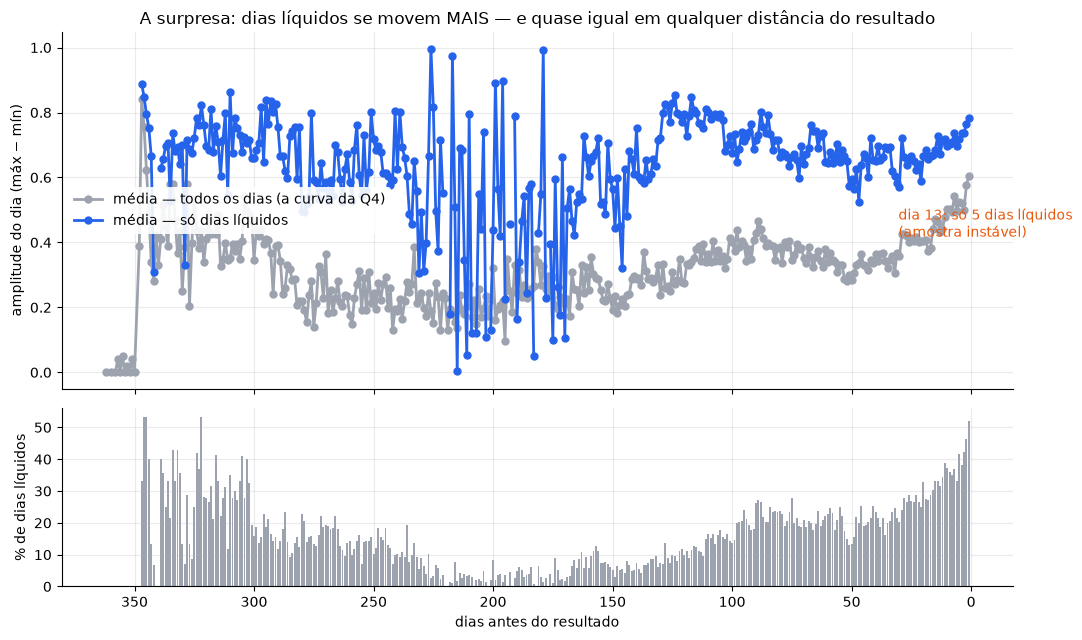

In [80]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

x = q5["dias_antes_do_resultado"]
ax1.plot(x, q5["amp_media_todos"], color=COR_VOLUME, lw=2, marker="o", ms=5,
         label="média — todos os dias (a curva da Q4)")
ax1.plot(x, q5["amp_media_liquida"], color=COR_PRECO, lw=2, marker="o", ms=5,
         label="média — só dias líquidos")
ax1.annotate("dia 13: só 5 dias líquidos\n(amostra instável)", xy=(13, 0.61),
             xytext=(-30, -45), textcoords="offset points", color=COR_DESTAQUE)
ax1.set_ylabel("amplitude do dia (máx − mín)")
ax1.legend(loc="center left", frameon=True, framealpha=0.9, edgecolor="none")
ax1.set_title("A surpresa: dias líquidos se movem MAIS — e quase igual em qualquer distância do resultado")

ax2.bar(x, q5["pct_liquidos"], color=COR_VOLUME)
ax2.set_ylabel("% de dias líquidos")
ax2.set_xlabel("dias antes do resultado")
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

Podemos ver que, da mesma forma que nos jogos de futebol os dias liquidos se movem mais, na política isso também se mostra uma tendência. 

Podemos ver uma instabilidade nessa amplitude próximo 200 dias antes do resultado, na qual por vezes os dias liquidos são menores que os dias gerais. Essa instabilidade se deve a baixa quantidade de dias liquidos nesse período. No entando, a tendência geral permanece.

### 3.2 Alerta 1 Funciona?

A query abaixo teve que ser modificada de um jeito um pouco mais significativo. Os mercados políticos se mostraram mais polarizados que os de futebol, de forma que a amplitude média (e mediana) era muito próxima de 0 ou de 1, então o piso não fazia muito sentido para mercados tão constrastantes. Da mesma forma, 3 vezes a media se mostrou numericamente impossível para, por exemplo, o mercado do Trump, que alcançava 0.8 e 0.9 de amplitude mediana com alguma regularidade. Assim, esse multiplicador foi alterado para 1. 

```SQL
WITH serie AS (
  SELECT
    d.market_id, m.event_title, d.trade_date,
    DATE_DIFF(DATE(m.end_date), d.trade_date, DAY)  AS dias_antes_do_jogo,
    d.daily_trade_count, d.daily_usd_volume, d.avg_trade_price,
    d.max_trade_price - d.min_trade_price           AS amplitude_dia
  FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` d
  JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m ON d.market_id = m.market_id
  WHERE LOWER(m.question) LIKE '%presidential election%'
        AND m.end_date <= '2026-07-25 23:59:59'
    AND m.volume > 100000
    AND DATE_DIFF(DATE(m.end_date), d.trade_date, DAY) BETWEEN 1 AND 365
),
baseline AS (
  SELECT
    dias_antes_do_jogo,
    APPROX_QUANTILES(IF(daily_trade_count >= 30 AND daily_usd_volume >= 1000,
                        amplitude_dia, NULL), 100)[OFFSET(50)] AS amp_tipica
  FROM serie
  GROUP BY dias_antes_do_jogo
)
SELECT
  s.market_id, s.event_title, s.trade_date, s.dias_antes_do_jogo,b.amp_tipica,
  s.daily_trade_count                          AS trades,
  ROUND(s.daily_usd_volume)                    AS volume_usd,
  ROUND(s.amplitude_dia, 3)                    AS amplitude_dia,
  ROUND(b.amp_tipica, 3)                       AS amp_tipica,
  ROUND(SAFE_DIVIDE(s.amplitude_dia, b.amp_tipica), 1) AS razao,
  (s.amplitude_dia >= 1 * b.amp_tipica         -- k = 1x o típico. Costumava a ser 3x
   AND s.daily_usd_volume >= 1000)             AS dispara
FROM serie s
JOIN baseline b USING (dias_antes_do_jogo)
WHERE s.market_id IN ('601819', '253591', '253597')
ORDER BY s.market_id, s.trade_date;
```

In [81]:
q6 = carrega("q6_teste_alerta_1.csv")

print("disparos por jogo:")
print(q6.groupby("market_id")["dispara"].sum().to_string())
print()
# O caso que TÍNHAMOS que pegar: a reprecificação do PSG (04-07/04)
q6[q6['dispara']==True][
    ["trade_date", "dias_antes_do_jogo", "trades", "volume_usd",
     "amplitude_dia", "amp_tipica", "razao", "dispara"]].sample(20)

disparos por jogo:
market_id
253591    17
253597    27
512340    19



,trade_date,dias_antes_do_jogo,trades,volume_usd,amplitude_dia,amp_tipica,razao,dispara
588,2024-11-08,30,197,2758.0,0.981,0.648,1.5,True
460,2024-06-30,127,486,58434.0,0.937,0.937,1.0,True
110,2024-04-24,195,53,130322.0,0.160,0.160,1.0,True
451,2024-06-21,136,59,8788.0,0.966,0.658,1.5,True
159,2024-06-12,146,471,88736.0,0.130,0.130,1.0,True
130,2024-05-14,175,159,35596.0,0.100,0.100,1.0,True
599,2024-11-19,19,160,9445.0,0.944,0.820,1.2,True
439,2024-06-09,148,68,1614.0,0.969,0.520,1.9,True
601,2024-11-21,17,383,3416.0,0.948,0.810,1.2,True
359,2024-03-02,247,31,2157.0,0.967,0.772,1.3,True


Podemos ver que, mesmo com as modificações feitas, esse teste não funciona para eleições, do mesmo jeito que não funcionava para o futebol. Temos alguns resultados positivos, mas eles não são perto da eleições.

Uma diferença relevante é que as medianas nesse caso são bem mais extremas, geralmente sendo muito alta (mais de 0,9) ou muito baixa (menos de 0,1).

Infelizmente, por conta do tempo curto, vamos assumir que essa régua captura para politica a mesma informação que captura para futebol e daremos seguimento para a régua ajustada.

## 3.3 Alerta 2 (Alerta 1 ajustado)

Bem, o último alerta não funcionou nem para futebol nem pra eleições. Vamos testar o alerta 2, que, partindo do 1, conseguiu, de forma satisfatória, deterctar flutuações no mercado. 

```SQL
WITH mercados AS (
  SELECT
    m.market_id,
    m.question,
    m.event_title,
    CAST(m.end_date AS DATE) AS data_evento
  FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
  WHERE LOWER(m.question) LIKE '%presidential election%'
        AND end_date <= '2026-07-25 23:59:59'
    AND m.volume > 100000
),

mercados_validos AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento
  FROM mercados
  WHERE data_evento IS NOT NULL
),

trades_normalizados AS (
  SELECT
    t.market_id,
    m.question,
    m.event_title,
    m.data_evento,
    t.trade_timestamp,
    SAFE_CAST(t.usd_amount AS FLOAT64) AS usd_amount,
    CASE
      WHEN t.nonusdc_side = 'token1'
        THEN SAFE_CAST(t.price AS FLOAT64)
      WHEN t.nonusdc_side = 'token2'
        THEN 1.0 - SAFE_CAST(t.price AS FLOAT64)
    END AS preco_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
  JOIN mercados_validos m
    ON t.market_id = m.market_id
  WHERE t.trade_timestamp <= '2026-07-25 23:59:59'
    -- Somente os 13 dias anteriores; o dia do evento fica fora.
    AND DATE(t.trade_timestamp) BETWEEN
        DATE_SUB(m.data_evento, INTERVAL 13 DAY)
        AND DATE_SUB(m.data_evento, INTERVAL 1 DAY)
    AND t.nonusdc_side IN ('token1', 'token2')
    AND SAFE_CAST(t.usd_amount AS FLOAT64) > 0
    AND SAFE_CAST(t.price AS FLOAT64) BETWEEN 0 AND 1
),

barras_horarias AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*) AS trades_hora,
    SUM(usd_amount) AS volume_hora,
    SAFE_DIVIDE(
      SUM(preco_yes * usd_amount),
      SUM(usd_amount)
    ) AS vwap_yes,
    MIN(preco_yes) AS preco_min_yes,
    MAX(preco_yes) AS preco_max_yes
  FROM trades_normalizados
  WHERE preco_yes IS NOT NULL
  GROUP BY
    market_id,
    question,
    event_title,
    data_evento,
    hora
),

comparacoes AS (
  -- A autojunção exige a hora UTC imediatamente anterior.
  -- Se não houve barra naquela hora, não há comparação nem sinal.
  SELECT
    atual.market_id,
    atual.question,
    atual.event_title,
    atual.data_evento,
    anterior.hora AS hora_anterior,
    atual.hora AS hora_atual,
    anterior.trades_hora AS trades_hora_anterior,
    anterior.volume_hora AS volume_hora_anterior,
    anterior.vwap_yes AS vwap_yes_anterior,
    anterior.preco_min_yes AS preco_min_yes_anterior,
    anterior.preco_max_yes AS preco_max_yes_anterior,
    atual.trades_hora AS trades_hora_atual,
    atual.volume_hora AS volume_hora_atual,
    atual.vwap_yes AS vwap_yes_atual,
    atual.preco_min_yes AS preco_min_yes_atual,
    atual.preco_max_yes AS preco_max_yes_atual,
    atual.vwap_yes - anterior.vwap_yes AS variacao_1h
  FROM barras_horarias atual
  JOIN barras_horarias anterior
    ON anterior.market_id = atual.market_id
   AND anterior.hora = TIMESTAMP_SUB(atual.hora, INTERVAL 1 HOUR)
  WHERE atual.trades_hora >= 20
    AND atual.volume_hora >= 1000
    AND anterior.trades_hora >= 20
    AND anterior.volume_hora >= 1000
),

sinais AS (
  SELECT *
  FROM comparacoes
  WHERE ABS(variacao_1h) >= 0.05
)

SELECT
  market_id,
  question,
  event_title,
  data_evento,
  DATE_DIFF(data_evento, DATE(hora_atual), DAY)
    AS dias_antes_do_evento,
  hora_anterior,
  hora_atual,
  trades_hora_anterior,
  ROUND(volume_hora_anterior, 2) AS volume_hora_anterior_usd,
  ROUND(vwap_yes_anterior, 4) AS vwap_yes_anterior,
  ROUND(preco_min_yes_anterior, 4) AS preco_min_yes_anterior,
  ROUND(preco_max_yes_anterior, 4) AS preco_max_yes_anterior,
  trades_hora_atual,
  ROUND(volume_hora_atual, 2) AS volume_hora_atual_usd,
  ROUND(vwap_yes_atual, 4) AS vwap_yes_atual,
  ROUND(preco_min_yes_atual, 4) AS preco_min_yes_atual,
  ROUND(preco_max_yes_atual, 4) AS preco_max_yes_atual,
  ROUND(variacao_1h, 4) AS variacao_1h,
  CASE
    WHEN variacao_1h > 0 THEN 'ALTA_BRUSCA'
    WHEN variacao_1h < 0 THEN 'BAIXA_BRUSCA'
  END AS movimento
FROM sinais
ORDER BY
  ABS(variacao_1h) DESC,
  volume_hora_atual DESC;
```

In [69]:
q7 = carrega("q7_alerta_2.csv")

# Tipos e invariantes da query: cada linha deve comparar duas horas consecutivas,
# líquidas e com preços já normalizados para a perspectiva do YES.
for col in ["hora_anterior", "hora_atual"]:
    q7[col] = pd.to_datetime(
        q7[col].astype(str).str.replace(" UTC", "", regex=False)
    )

colunas_obrigatorias = {
    "market_id", "event_title", "hora_anterior", "hora_atual",
    "trades_hora_anterior", "trades_hora_atual",
    "volume_hora_anterior_usd", "volume_hora_atual_usd",
    "vwap_yes_anterior", "vwap_yes_atual", "variacao_1h", "movimento",
}
assert colunas_obrigatorias.issubset(q7.columns)
assert not q7[list(colunas_obrigatorias)].isna().any().any()
assert not q7.duplicated(["market_id", "hora_atual"]).any()
assert ((q7["hora_atual"] - q7["hora_anterior"]) == pd.Timedelta(hours=1)).all()
assert (q7[["trades_hora_anterior", "trades_hora_atual"]] >= 20).all().all()
assert (q7[["volume_hora_anterior_usd", "volume_hora_atual_usd"]] >= 1000).all().all()
assert q7[["vwap_yes_anterior", "vwap_yes_atual"]].apply(lambda s: s.between(0, 1)).all().all()
assert (q7["variacao_1h"].abs() >= 0.05).all()
assert ((q7["vwap_yes_atual"] - q7["vwap_yes_anterior"] - q7["variacao_1h"]).abs() <= 0.0002).all()
assert (((q7["variacao_1h"] > 0) & (q7["movimento"] == "ALTA_BRUSCA")) |
        ((q7["variacao_1h"] < 0) & (q7["movimento"] == "BAIXA_BRUSCA"))).all()

# Uma partida pode gerar dois sinais na mesma hora, um para cada mercado complementar.
episodios = q7.drop_duplicates(["event_title", "hora_atual"])
q7["abs_variacao_1h"] = q7["variacao_1h"].abs()
q7["faixa_atual"] = q7["preco_max_yes_atual"] - q7["preco_min_yes_atual"]

# Heurísticas conservadoras de triagem — são indícios, não rótulos verdadeiros.
q7["vwap_extremo"] = (q7["vwap_yes_atual"] <= 0.05) | (q7["vwap_yes_atual"] >= 0.95)
q7["varrida"] = q7["faixa_atual"] >= 0.80
q7["salto_extremo"] = q7["abs_variacao_1h"] >= 0.30
q7["calendario_leicester"] = q7["event_title"].eq(
    "Leicester City FC vs. Southampton FC"
)
q7["suspeito"] = q7[[
    "vwap_extremo", "varrida", "salto_extremo", "calendario_leicester"
]].any(axis=1)

print(f"sinais: {len(q7)} | mercados: {q7['market_id'].nunique()} | "
      f"partidas: {q7['event_title'].nunique()} | episódios partida-hora: {len(episodios)}")
print(f"direção: {q7['movimento'].value_counts().to_dict()}")
print(f"|ΔPMPV| — mediana {q7['abs_variacao_1h'].median():.5f}; "
      f"máximo {q7['abs_variacao_1h'].max():.4f}")
print(f"atividade mediana — anterior: {q7['trades_hora_anterior'].median():.1f} negociações / "
      f"US${q7['volume_hora_anterior_usd'].median():,.0f}; "
      f"atual: {q7['trades_hora_atual'].median():.1f} negociações / "
      f"US${q7['volume_hora_atual_usd'].median():,.0f}")
print(f"D−1: {(q7['dias_antes_do_evento'] == 1).sum()}/{len(q7)} sinais")
print(f"marcadores — PMPV extremo: {q7['vwap_extremo'].sum()}; "
      f"varrida atual: {q7['varrida'].sum()}; salto >= 0,30: {q7['salto_extremo'].sum()}; "
      f"Leicester contaminado: {q7['calendario_leicester'].sum()}")
print(f"triagem conservadora: {q7['suspeito'].sum()}/{len(q7)} com ao menos um marcador")
print(f"PSG 1733047 presente? {(q7['market_id'].astype(str) == '1733047').any()}")

q7.sort_values(
    ["suspeito", "abs_variacao_1h"], ascending=[False, False]
)[[
    "event_title", "dias_antes_do_evento", "hora_atual", "movimento",
    "vwap_yes_anterior", "vwap_yes_atual", "variacao_1h", "faixa_atual",
    "vwap_extremo", "varrida", "salto_extremo", "calendario_leicester", "suspeito",
]].head(12)

sinais: 70 | mercados: 23 | partidas: 14 | episódios partida-hora: 54
direção: {'BAIXA_BRUSCA': 36, 'ALTA_BRUSCA': 34}
|ΔPMPV| — mediana 0.06540; máximo 0.5236
atividade mediana — anterior: 124.0 negociações / US$8,654; atual: 224.0 negociações / US$14,463
D−1: 5/70 sinais
marcadores — PMPV extremo: 6; varrida atual: 1; salto >= 0,30: 2; Leicester contaminado: 0
triagem conservadora: 9/70 com ao menos um marcador
PSG 1733047 presente? False


,event_title,dias_antes_do_evento,hora_atual,movimento,vwap_yes_anterior,vwap_yes_atual,variacao_1h,faixa_atual,vwap_extremo,varrida,salto_extremo,calendario_leicester,suspeito
0,Taiwan Presidential Election: Who will win?,1,2024-01-12 19:00:00,ALTA_BRUSCA,0.2648,0.7884,0.5236,0.090,False,False,True,False,True
1,Portugal Presidential Election: 1st Round 2nd ...,7,2026-01-18 19:00:00,ALTA_BRUSCA,0.5431,0.8483,0.3052,0.350,False,False,True,False,True
9,Portugal Presidential Election,7,2026-01-18 19:00:00,BAIXA_BRUSCA,0.1950,0.0429,-0.1521,0.163,True,False,False,False,True
10,(Old) Romania Election,2,2024-12-06 13:00:00,ALTA_BRUSCA,0.0132,0.1649,0.1517,0.954,False,True,False,False,True
12,Portugal Presidential Election: 1st Round 2nd ...,7,2026-01-18 20:00:00,ALTA_BRUSCA,0.8483,0.9790,0.1307,0.123,True,False,False,False,True
13,Portugal Presidential Election: 1st Round Winner,7,2026-01-18 20:00:00,ALTA_BRUSCA,0.8662,0.9903,0.1241,0.092,True,False,False,False,True
14,Portugal Presidential Election: 1st Round Winner,7,2026-01-18 20:00:00,BAIXA_BRUSCA,0.1372,0.0132,-0.1240,0.099,True,False,False,False,True
37,Peru Presidential Election First Round Winner,4,2026-04-08 00:00:00,BAIXA_BRUSCA,0.0809,0.0166,-0.0643,0.049,True,False,False,False,True
61,Portugal Presidential Election: 1st Round 2nd ...,7,2026-01-18 20:00:00,BAIXA_BRUSCA,0.0736,0.0208,-0.0528,0.098,True,False,False,False,True
2,Portugal Presidential Election: 1st Round Winner,7,2026-01-18 19:00:00,ALTA_BRUSCA,0.6665,0.8662,0.1997,0.250,False,False,False,False,False


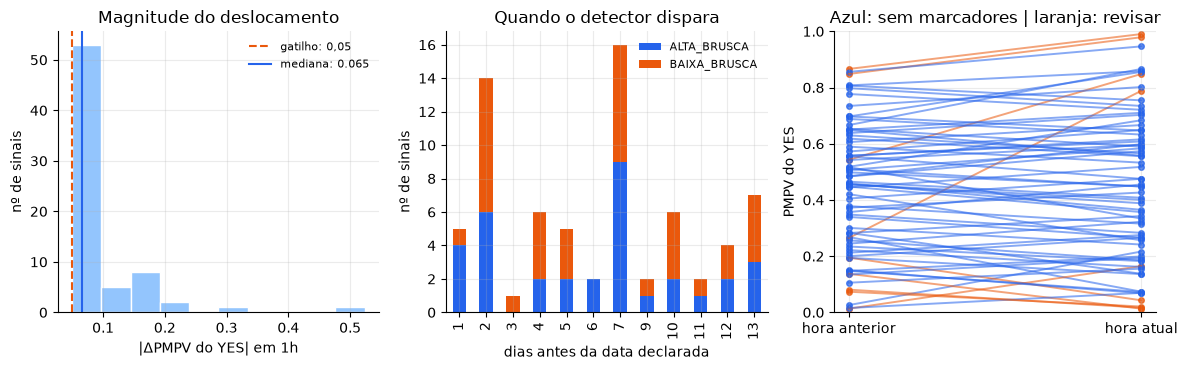

In [70]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.8))

# 1. Magnitude dos deslocamentos detectados.
ax1.hist(q7["abs_variacao_1h"], bins=10, color=COR_BANDA, edgecolor="white")
ax1.axvline(0.05, color=COR_DESTAQUE, ls="--", lw=1.5, label="gatilho: 0,05")
ax1.axvline(q7["abs_variacao_1h"].median(), color=COR_PRECO, lw=1.5,
            label=f"mediana: {q7['abs_variacao_1h'].median():.3f}")
ax1.set_xlabel("|ΔPMPV do YES| em 1h")
ax1.set_ylabel("nº de sinais")
ax1.set_title("Magnitude do deslocamento")
ax1.legend(frameon=False, fontsize=8)

# 2. Distância da data declarada, separada por direção.
timing = (q7.groupby(["dias_antes_do_evento", "movimento"])
          .size().unstack(fill_value=0).sort_index())
timing.plot(
    kind="bar", stacked=True, ax=ax2,
    color={"ALTA_BRUSCA": COR_PRECO, "BAIXA_BRUSCA": COR_DESTAQUE},
)
ax2.set_xlabel("dias antes da data declarada")
ax2.set_ylabel("nº de sinais")
ax2.set_title("Quando o detector dispara")
ax2.legend(frameon=False, fontsize=8)

# 3. Antes e depois: laranja indica ao menos um marcador da triagem conservadora.
for _, r in q7.iterrows():
    cor = COR_DESTAQUE if r["suspeito"] else COR_PRECO
    ax3.plot([0, 1], [r["vwap_yes_anterior"], r["vwap_yes_atual"]],
             color=cor, alpha=0.55, lw=1.4)
    ax3.scatter([0, 1], [r["vwap_yes_anterior"], r["vwap_yes_atual"]],
                color=cor, s=16, alpha=0.75)
ax3.set_xticks([0, 1], ["hora anterior", "hora atual"])
ax3.set_ylim(0, 1)
ax3.set_ylabel("PMPV do YES")
ax3.set_title("Azul: sem marcadores | laranja: revisar")

plt.tight_layout()
plt.show()

Temos, novamente, conclusões parecidas. Por mais que os mercados políticos tenham mais interações, os comportamentos são semelhantes.

No entanto, podemos vez que esse alerta funciona um pouco pior para eleições. O detector disparou bastante no com 2 dias pro resultado, mas com 1 dia quase não vemos resultado. Além disso, 7 dias antes do resultado foi o com mais disparos, sem um motivo evidente.

## 4 Conclusão

Por mais que política e futebol tenham suas semelhantes no que diz respeito ao aumento de volume a amplitude nos mercados do Polymarket, política tem um volume muito maior e dura muito mais tempo. Além disso, existem fatores que fazem com que um alerta que funciona razoavelmente para futebol não seja muito adequado para política. 